## Potrzebne biblioteki

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim

import torchvision
from torchvision import transforms, datasets

## Wybór urządzenia

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## Zbiór danych

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.ImageFolder("trafic_32", transform=transform)
# dataloader = data.DataLoader(dataset, batch_size=128, shuffle=True)

## Rozkład próbek w klasach

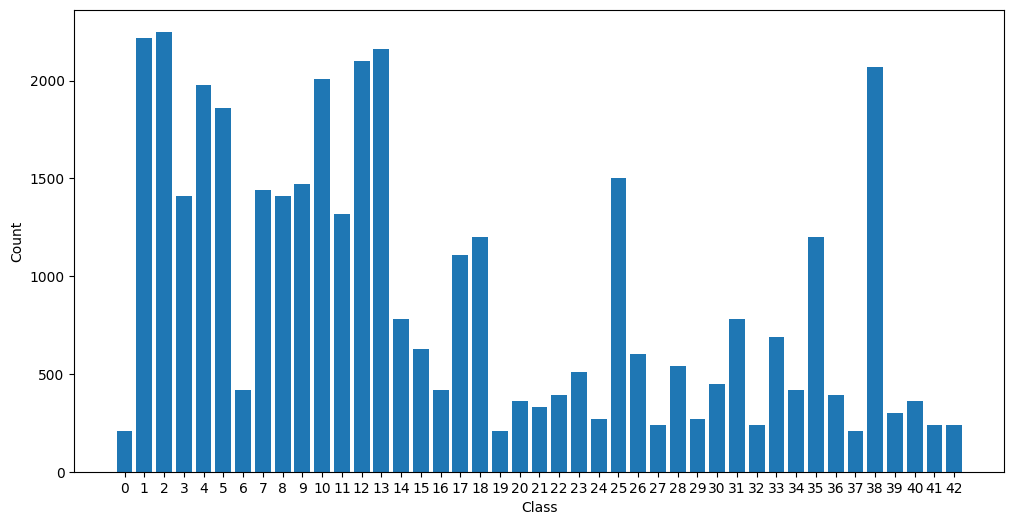

In [4]:
class_counts = Counter(dataset.targets)

classes = list(class_counts.keys())
counts = [class_counts[c] for c in classes]

plt.figure(figsize=(12, 6))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(classes)
plt.show()

## Ważenie próbek

In [5]:
counts = np.bincount(dataset.targets)
weights = 1.0 / counts

sample_weights = [weights[t] for t in dataset.targets]

sampler = data.WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

dataloader = data.DataLoader(dataset, batch_size=128, sampler=sampler)

## Architektura GAN

In [6]:
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Discriminator, self).__init__()

        self.conv_1 = nn.Conv2d(input_dim, hidden_dim, 4, 2, 1, bias=False)

        self.conv_2 = nn.Conv2d(hidden_dim, hidden_dim * 2, 4, 2, 1, bias=False)
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 4, 2, 1, bias=False)
        self.bn_3 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_out = nn.Conv2d(hidden_dim * 4, 1, 4, 1, 0, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.act(self.conv_1(x))
        x = self.act(self.bn_2(self.conv_2(x)))
        x = self.act(self.bn_3(self.conv_3(x)))

        x = torch.sigmoid(self.conv_out(x))
        return torch.flatten(x)


class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Generator, self).__init__()

        self.conv_1 = nn.ConvTranspose2d(
            latent_dim, hidden_dim * 4, 4, 1, 0, bias=False
        )
        self.bn_1 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_2 = nn.ConvTranspose2d(
            hidden_dim * 4, hidden_dim * 2, 4, 2, 1, bias=False
        )
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.ConvTranspose2d(
            hidden_dim * 2, hidden_dim, 4, 2, 1, bias=False
        )
        self.bn_3 = nn.BatchNorm2d(hidden_dim)

        self.conv_4 = nn.ConvTranspose2d(hidden_dim, output_dim, 4, 2, 1, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.act(self.bn_1(self.conv_1(x)))
        h = self.act(self.bn_2(self.conv_2(h)))
        h = self.act(self.bn_3(self.conv_3(h)))

        x_hat = torch.sigmoid(self.conv_4(h))
        return x_hat

## Inicjalizacja sieci

In [7]:
latent_dim = 128
hidden_dim = 64
channels = 3
num_classes = len(dataset.class_to_idx)

generator = Generator(
    latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=channels
).to(device)

discriminator = Discriminator(input_dim=channels, hidden_dim=hidden_dim).to(device)


generator_optimizer = torch.optim.Adam(
    generator.parameters(), lr=0.0004, betas=(0.5, 0.999)
)
generator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=generator_optimizer, gamma=0.99
)
discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999)
)
discriminator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=discriminator_optimizer, gamma=0.99
)

criterion = nn.BCELoss()

In [8]:
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

## Pętla treningowa

Epoch: 0, discriminator fake error: 0.462, discriminator real acc: 0.528


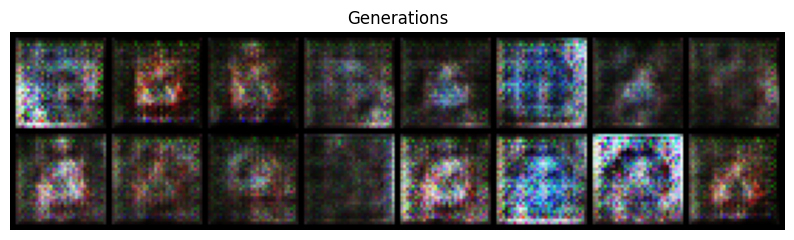

Epoch: 1, discriminator fake error: 0.463, discriminator real acc: 0.532
Epoch: 2, discriminator fake error: 0.443, discriminator real acc: 0.550
Epoch: 3, discriminator fake error: 0.444, discriminator real acc: 0.552
Epoch: 4, discriminator fake error: 0.422, discriminator real acc: 0.574
Epoch: 5, discriminator fake error: 0.392, discriminator real acc: 0.604
Epoch: 6, discriminator fake error: 0.360, discriminator real acc: 0.636
Epoch: 7, discriminator fake error: 0.331, discriminator real acc: 0.667
Epoch: 8, discriminator fake error: 0.300, discriminator real acc: 0.697
Epoch: 9, discriminator fake error: 0.279, discriminator real acc: 0.719
Epoch: 10, discriminator fake error: 0.260, discriminator real acc: 0.738


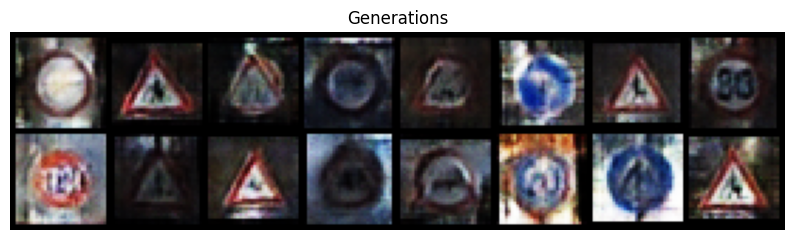

Epoch: 11, discriminator fake error: 0.240, discriminator real acc: 0.758
Epoch: 12, discriminator fake error: 0.224, discriminator real acc: 0.774
Epoch: 13, discriminator fake error: 0.212, discriminator real acc: 0.786
Epoch: 14, discriminator fake error: 0.204, discriminator real acc: 0.794
Epoch: 15, discriminator fake error: 0.190, discriminator real acc: 0.809
Epoch: 16, discriminator fake error: 0.169, discriminator real acc: 0.829
Epoch: 17, discriminator fake error: 0.169, discriminator real acc: 0.830
Epoch: 18, discriminator fake error: 0.154, discriminator real acc: 0.845
Epoch: 19, discriminator fake error: 0.160, discriminator real acc: 0.839
Epoch: 20, discriminator fake error: 0.139, discriminator real acc: 0.861


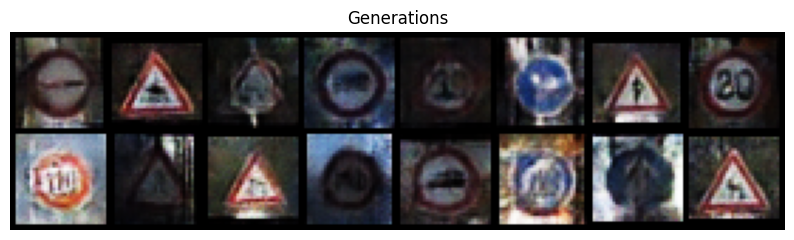

Epoch: 21, discriminator fake error: 0.137, discriminator real acc: 0.861
Epoch: 22, discriminator fake error: 0.132, discriminator real acc: 0.867
Epoch: 23, discriminator fake error: 0.123, discriminator real acc: 0.877
Epoch: 24, discriminator fake error: 0.112, discriminator real acc: 0.886
Epoch: 25, discriminator fake error: 0.123, discriminator real acc: 0.877
Epoch: 26, discriminator fake error: 0.129, discriminator real acc: 0.871
Epoch: 27, discriminator fake error: 0.100, discriminator real acc: 0.898
Epoch: 28, discriminator fake error: 0.097, discriminator real acc: 0.903
Epoch: 29, discriminator fake error: 0.100, discriminator real acc: 0.899
Epoch: 30, discriminator fake error: 0.100, discriminator real acc: 0.899


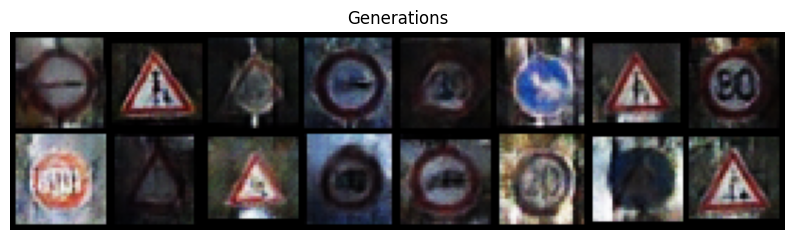

Epoch: 31, discriminator fake error: 0.085, discriminator real acc: 0.914
Epoch: 32, discriminator fake error: 0.101, discriminator real acc: 0.898
Epoch: 33, discriminator fake error: 0.079, discriminator real acc: 0.920
Epoch: 34, discriminator fake error: 0.085, discriminator real acc: 0.914
Epoch: 35, discriminator fake error: 0.073, discriminator real acc: 0.926
Epoch: 36, discriminator fake error: 0.076, discriminator real acc: 0.923
Epoch: 37, discriminator fake error: 0.082, discriminator real acc: 0.918
Epoch: 38, discriminator fake error: 0.066, discriminator real acc: 0.933
Epoch: 39, discriminator fake error: 0.086, discriminator real acc: 0.914
Epoch: 40, discriminator fake error: 0.061, discriminator real acc: 0.939


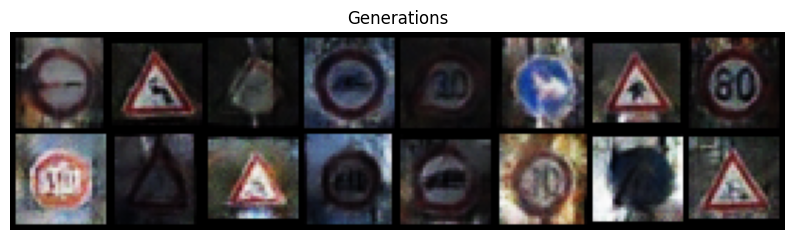

Epoch: 41, discriminator fake error: 0.083, discriminator real acc: 0.916
Epoch: 42, discriminator fake error: 0.057, discriminator real acc: 0.943
Epoch: 43, discriminator fake error: 0.060, discriminator real acc: 0.940
Epoch: 44, discriminator fake error: 0.075, discriminator real acc: 0.925
Epoch: 45, discriminator fake error: 0.055, discriminator real acc: 0.944


KeyboardInterrupt: 

In [9]:
G_losses = []
D_losses = []
num_epochs = 100
for epoch in range(num_epochs):
    sum_d_fake_acc = torch.tensor(0.0, device=device)
    sum_d_real_acc = torch.tensor(0.0, device=device)
    sum_g_loss = torch.tensor(0.0, device=device)
    sum_d_loss = torch.tensor(0.0, device=device)

    num_batches = 0

    for i, data in enumerate(dataloader, 0):
        num_batches += 1
        ####################
        # Update D network #
        ####################

        ## Train with all-real batch
        discriminator_optimizer.zero_grad()

        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.ones((b_size,), dtype=torch.float, device=device)

        output = discriminator(real_images).view(-1)
        error_discriminator_real = criterion(output, label)
        sum_d_real_acc += output.mean().detach()

        ## Train with all-fake batch
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)

        fake_images = generator(noise)
        label_fake = torch.zeros((b_size,), dtype=torch.float, device=device)

        output = discriminator(fake_images.detach()).view(-1)
        error_discriminator_fake = criterion(output, label_fake)
        sum_d_fake_acc += output.mean().detach()

        error_discriminator = error_discriminator_real + error_discriminator_fake
        sum_d_loss += error_discriminator.detach()

        error_discriminator.backward()

        discriminator_optimizer.step()

        ####################
        # Update G network #
        ####################
        generator_optimizer.zero_grad()
        label = torch.ones((b_size,), dtype=torch.float, device=device)

        output = discriminator(fake_images).view(-1)
        error_generator = criterion(output, label)
        error_generator.backward()

        generator_optimizer.step()

        sum_g_loss += error_generator.detach()

    avg_d_fake_acc = (sum_d_fake_acc / num_batches).item()
    avg_d_real_acc = (sum_d_real_acc / num_batches).item()
    avg_g_loss = (sum_g_loss / num_batches).item()
    avg_d_loss = (sum_d_loss / num_batches).item()

    G_losses.append(avg_g_loss)
    D_losses.append(avg_d_loss)

    print(
        f"Epoch: {epoch}, discriminator fake error: {avg_d_fake_acc:.3f}, discriminator real acc: {avg_d_real_acc:.3f}"
    )
    generator_scheduler.step()
    discriminator_scheduler.step()
    if epoch % 10 == 0:
        with torch.no_grad():
            fake = generator(fixed_noise).detach().cpu()
        grid = torchvision.utils.make_grid(fake)
        grid = grid.permute(1, 2, 0)
        plt.figure(figsize=(10, 10))
        plt.title(f"Generations")
        plt.imshow(grid)
        plt.axis("off")
        plt.show()